In [ ]:
with open("book_training_data.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()
print('total number of characters: ', len(raw_text))
print(raw_text[:1199])


total number of characters:  456795
Virus programming (basics) #1...
This section is dedicated to those who would like to write a virus, but don't have the
knowledge to do so.  First of all, writing a virus is no big deal.  It is an easy project, but one
which requires some basic programmin g skills, and the desire to write a virus!  If either of
these is missing, writing a virus would be tedious indeed!.
 Well, if you meet these requisites, keep reading this article....
               JE   READ
               JNE  FUCK_YOU!
READ:
The survival of a virus is based in its ability to reproduce.  "So how the fuck do I make a
program reproduce?", you might ask. Simple, by getting it to copy itself to other files....
The functional logic of a virus is as follows:
1- Search for a file to infect
2- Open the file to see if it is infected
3- If infected, search for another file
4- Else, infect the file
5- Return control to the host program.
The following is an example of a simple virus:
;*******

In [ ]:
import re
text = raw_text[:99]
result = re.split(r'([,.:;?_!"()\#]|--|\s)', text)
result = [item for item in result if item.strip()]
print(result)

['Virus', 'programming', '(', 'basics', ')', '#', '1', '.', '.', '.', 'This', 'section', 'is', 'dedicated', 'to', 'those', 'who', 'would', 'like', 'to', 'write', 'a', 'virus']


In [ ]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])

['Virus', 'programming', '(', 'basics', ')', '#1', '.', '.', '.', 'This', 'section', 'is', 'dedicated', 'to', 'those', 'who', 'would', 'like', 'to', 'write', 'a', 'virus', ',', 'but', 'don', "'", 't', 'have', 'the', 'knowledge']


In [ ]:
print(len(preprocessed))

88214


In [ ]:
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)

print(vocab_size)

13095


In [ ]:
vocab = {token:integer for integer, token in enumerate(all_words)}

In [ ]:
for i, item in enumerate(vocab.items()):
  print(item)
  if i >= 5:
    break

('\x1a', 0)
('!', 1)
('"', 2)
('#', 3)
('##', 4)
('############', 5)


In [ ]:
class SimpleTokenizerV1:
  def __init__(self, vocab):
    self.str_to_int = vocab
    self.int_to_str = {i:s for s, i in vocab.items()}
  def encode(self, text):
    preprocessed = re.split(r'([,.:;?_!"()#\']|--|\s)', text)

    preprocessed = [
        item.strip() for item in preprocessed if item.strip()
    ]
    ids = [self.str_to_int[s] for s in preprocessed]
    return ids
  def decode(self, ids):
    text = " ".join([self.int_to_str[i] for i in ids])
    text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
    return text

In [ ]:
tokenizer = SimpleTokenizerV1(vocab)

text = raw_text[200:300]
ids = tokenizer.encode(text)
print(ids)

[13002, 11269, 111, 7961, 10852, 12896, 11579, 12020, 7761, 11265, 9448, 11976, 111, 7557, 12395, 8654, 12467, 12985, 7344, 12796, 1]


In [ ]:
tokenizer.decode(ids)

'y project, but one which requires some basic programmin g skills, and the desire to write a virus!'

In [ ]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])

vocab = {token:integer for integer, token in enumerate(all_tokens)}

In [ ]:
len(vocab.items())

13097

In [ ]:
for i, item in enumerate(list(vocab.items())[-5:]):
  print(item)

('ŒLECTRONIC', 13092)
('ŒLectronic', 13093)
('Œzine', 13094)
('<|endoftext|>', 13095)
('<|unk|>', 13096)


In [ ]:
class SimpleTokenizerV2:
  def __init__(self, vocab):
    self.str_to_int = vocab
    self.int_to_str = { i:s for s, i in vocab.items()}
  def encode(self, text):
    preprocessed = re.split(r'([,.:;?!"()#\']|--|\s)', text)
    preprocessed = [item.strip() for item in preprocessed if item.strip()]
    preprocessed = [
        item if item in self.str_to_int
        else "<|unk|>" for item in preprocessed
    ]
    ids = [self.str_to_int[s] for s in preprocessed]
    return ids
  def decode(self, ids):
    text = " ".join([self.int_to_str[i] for i in ids])
    text = re.sub(r'\s+([,.:;?!"()#\'])', r'\1', text)
    return text

In [ ]:
tokenizer = SimpleTokenizerV2(vocab)
text1 = "hello, I am a Virus!"
text2 = raw_text[100:200]
text = " <|endoftext|> ".join((text1, text2))

print(text)

hello, I am a Virus! <|endoftext|>  but don't have the
knowledge to do so.  First of all, writing a virus is no big deal.  It is an eas


In [ ]:
tokenizer.encode(text)

[9669,
 111,
 4293,
 7535,
 7344,
 6814,
 1,
 13095,
 7961,
 8836,
 44,
 12290,
 9645,
 12395,
 10126,
 12467,
 8818,
 12005,
 244,
 3872,
 10814,
 7500,
 111,
 12989,
 7344,
 12796,
 10017,
 10731,
 7832,
 8560,
 244,
 4466,
 10017,
 7546,
 13096]

In [ ]:
tokenizer.decode(tokenizer.encode(text))

"hello, I am a Virus! <|endoftext|> but don' t have the knowledge to do so. First of all, writing a virus is no big deal. It is an <|unk|>"

In [ ]:
!pip install tiktoken

In [ ]:
import importlib
import tiktoken

print(importlib.metadata.version("tiktoken"))

0.12.0


In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")


In [ ]:
text = raw_text[100:1000]
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

print(integers)

[475, 836, 470, 423, 262, 198, 45066, 284, 466, 523, 13, 220, 3274, 286, 477, 11, 3597, 257, 9471, 318, 645, 1263, 1730, 13, 220, 632, 318, 281, 2562, 1628, 11, 475, 530, 198, 4758, 4433, 617, 4096, 1430, 1084, 308, 4678, 11, 290, 262, 6227, 284, 3551, 257, 9471, 0, 220, 1002, 2035, 286, 198, 27218, 318, 4814, 11, 3597, 257, 9471, 561, 307, 32460, 5600, 43179, 198, 3894, 11, 611, 345, 1826, 777, 1038, 31327, 11, 1394, 3555, 428, 2708, 1106, 198, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 449, 36, 220, 220, 20832, 198, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 220, 449, 12161, 220, 30998, 62, 36981, 0, 198, 15675, 25, 198, 464, 9441, 286, 257, 9471, 318, 1912, 287, 663, 2694, 284, 22919, 13, 220, 366, 2396, 703, 262, 5089, 466, 314, 787, 257, 198, 23065, 22919, 35379, 345, 1244, 1265, 13, 17427, 11, 416, 1972, 340, 284, 4866, 2346, 284, 584, 3696, 1106, 198, 464, 10345, 9156, 286, 257, 9471, 318, 355, 5679, 25, 198, 16, 12, 11140, 329, 2

In [ ]:
enc_text = tokenizer.encode(raw_text)

In [ ]:
enc_sample = enc_text[50:]
print(enc_sample[100:200])

[198, 15675, 25, 198, 464, 9441, 286, 257, 9471, 318, 1912, 287, 663, 2694, 284, 22919, 13, 220, 366, 2396, 703, 262, 5089, 466, 314, 787, 257, 198, 23065, 22919, 35379, 345, 1244, 1265, 13, 17427, 11, 416, 1972, 340, 284, 4866, 2346, 284, 584, 3696, 1106, 198, 464, 10345, 9156, 286, 257, 9471, 318, 355, 5679, 25, 198, 16, 12, 11140, 329, 257, 2393, 284, 7580, 198, 17, 12, 4946, 262, 2393, 284, 766, 611, 340, 318, 14112, 198, 18, 12, 1002, 14112, 11, 2989, 329, 1194, 2393, 198, 19, 12, 25974, 11, 7580, 262, 2393, 198, 20, 12]


In [ ]:
context_size = 6

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:  {y}")

x: [632, 318, 281, 2562, 1628, 11]
y:  [318, 281, 2562, 1628, 11, 475]


In [ ]:
for i in range(1, context_size+1):
  context = enc_sample[:i]
  desired = enc_sample[i]

  print(context, "-> ", desired)

[632] ->  318
[632, 318] ->  281
[632, 318, 281] ->  2562
[632, 318, 281, 2562] ->  1628
[632, 318, 281, 2562, 1628] ->  11
[632, 318, 281, 2562, 1628, 11] ->  475


In [ ]:
for i in range(1, context_size+1):
  context = enc_sample[:i]
  desired = enc_sample[i]

  print(tokenizer.decode(context), "-> ", tokenizer.decode([desired]))


 It ->   is
 It is ->   an
 It is an ->   easy
 It is an easy ->   project
 It is an easy project ->  ,
 It is an easy project, ->   but


In [ ]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
  def __init__(self, txt, tokenizer, max_length, stride):
    self.input_ids = []
    self.target_ids = []

    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i:i + max_length]
      target_chunk = token_ids[i+1: i + max_length + 1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx]

In [ ]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
  tokenizer = tiktoken.get_encoding("gpt2")
  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

  dataloader = DataLoader(
      dataset,
      batch_size = batch_size,
      shuffle=shuffle,
      drop_last = drop_last,
      num_workers = num_workers
  )
  return dataloader

In [ ]:
import torch
print(torch.__version__)
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)
second_batch = next(data_iter)
print(second_batch)

2.10.0+cpu
[tensor([[   53, 19397,  8300,   357]]), tensor([[19397,  8300,   357, 12093]])]
[tensor([[19397,  8300,   357, 12093]]), tensor([[ 8300,   357, 12093,   873]])]


In [ ]:
input_ids = torch.tensor([2, 3, 5, 1])

In [ ]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [ ]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [ ]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [ ]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


In [ ]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)


In [ ]:
max_length = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=max_length,
    stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

In [ ]:
print(inputs)
print(inputs.shape)

tensor([[   53, 19397,  8300,   357],
        [12093,   873,     8,  1303],
        [   16,   986,   198,  1212],
        [ 2665,   318,  7256,   284],
        [  883,   508,   561,   588],
        [  284,  3551,   257,  9471],
        [   11,   475,   836,   470],
        [  423,   262,   198, 45066]])
torch.Size([8, 4])


In [ ]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


In [ ]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

In [ ]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


In [ ]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings)

tensor([[[ 0.6183,  0.0083, -1.0601,  ..., -1.2231,  1.6767, -0.1138],
         [ 2.4315, -2.1614, -0.4594,  ..., -0.7190,  0.8975,  0.5971],
         [ 1.3166, -1.7556, -0.3166,  ...,  1.7753, -0.9267,  0.8272],
         [-1.5930, -0.2152,  1.9073,  ...,  0.7355, -0.2674,  1.4191]],

        [[ 0.6778, -2.3473, -0.7101,  ...,  0.8175,  0.5759,  0.9971],
         [ 2.1847, -1.0618,  0.2006,  ...,  0.0749, -1.2147,  0.0291],
         [-1.5877,  0.0604,  1.6516,  ...,  1.7620, -1.0171,  0.7853],
         [ 0.0268,  0.1923,  1.2563,  ..., -0.4499, -1.2653, -0.9406]],

        [[ 2.3791,  0.4085, -2.8001,  ..., -0.9910,  1.7226,  1.0299],
         [ 3.1692, -0.8866, -0.8283,  ...,  0.6905, -0.6344, -1.4808],
         [-0.6088, -1.7539,  2.1724,  ...,  1.7403, -1.6098,  0.1377],
         [-0.2354,  0.7237,  1.5216,  ...,  1.2395, -0.3763, -0.6861]],

        ...,

        [[ 0.7802,  0.1387,  0.7277,  ...,  1.7101, -0.3304, -0.1471],
         [ 1.3971, -1.2943, -0.4832,  ...,  0.9659,  0.37

In [ ]:
inputs = torch.tensor(
    [[0.413, 0.115, 0.829],
    [0.515, 0.827, 0.636],
    [0.567, 0.885, 0.674],
    [0.202, 0.518, 0.333],
    [0.797, 0.205, 0.110],
    [0.05, 0.810, 0.545]]
)

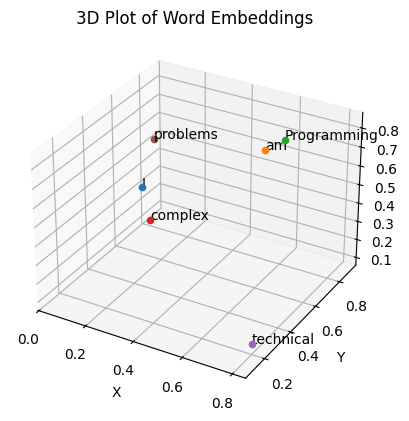

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

words = ['I', 'am', 'Programming', 'complex', 'technical', 'problems']

x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
  ax.scatter(x, y, z)
  ax.text(x, y, z, word, fontsize=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

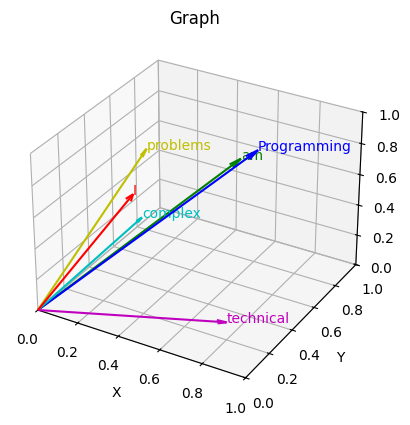

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'c', 'm', 'y']

for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
  ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
  ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('Graph')
plt.show()

In [ ]:
query = inputs[1]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
  attn_scores_2[i] = torch.dot(x_i, query)

print(attn_scores_2)

tensor([0.8350, 1.3536, 1.4526, 0.7442, 0.6499, 1.0422])


In [ ]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

print("Attention weights: ", attn_weights_2_tmp)
print("Sum: ", attn_weights_2_tmp.sum())

Attention weights:  tensor([0.1374, 0.2227, 0.2390, 0.1224, 0.1069, 0.1715])
Sum:  tensor(1.)


In [ ]:
def softmax_naive(x):
  return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights:", attn_weights_2_naive)
print("sum: ", attn_weights_2_naive.sum())

Attention weights: tensor([0.1332, 0.2237, 0.2470, 0.1216, 0.1107, 0.1638])
sum:  tensor(1.0000)


In [ ]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print(attn_weights_2)
print(attn_weights_2.sum())

tensor([0.1332, 0.2237, 0.2470, 0.1216, 0.1107, 0.1638])
tensor(1.)


In [ ]:
query = inputs[1]

context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
  context_vec_2 += attn_weights_2[i]*x_i
print(context_vec_2)

tensor([0.4312, 0.6373, 0.5611])


In [ ]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.8710, 0.8350, 0.8947, 0.4191, 0.4439, 0.5656],
        [0.8350, 1.3536, 1.4526, 0.7442, 0.6499, 1.0422],
        [0.8947, 1.4526, 1.5590, 0.7974, 0.7075, 1.1125],
        [0.4191, 0.7442, 0.7974, 0.4200, 0.3038, 0.6112],
        [0.4439, 0.6499, 0.7075, 0.3038, 0.6893, 0.2659],
        [0.5656, 1.0422, 1.1125, 0.6112, 0.2659, 0.9556]])


In [ ]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.1994, 0.1924, 0.2042, 0.1269, 0.1301, 0.1469],
        [0.1332, 0.2237, 0.2470, 0.1216, 0.1107, 0.1638],
        [0.1304, 0.2278, 0.2533, 0.1183, 0.1081, 0.1621],
        [0.1439, 0.1992, 0.2101, 0.1441, 0.1283, 0.1744],
        [0.1535, 0.1886, 0.1998, 0.1334, 0.1962, 0.1285],
        [0.1315, 0.2118, 0.2273, 0.1377, 0.0975, 0.1943]])


In [ ]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4339, 0.5742, 0.5620],
        [0.4312, 0.6373, 0.5611],
        [0.4330, 0.6423, 0.5633],
        [0.4212, 0.6095, 0.5448],
        [0.4636, 0.5638, 0.5179],
        [0.4075, 0.6401, 0.5594]])


In [ ]:
inputs = torch.tensor(
    [[0.413, 0.115, 0.829],
    [0.515, 0.827, 0.636],
    [0.567, 0.885, 0.674],
    [0.202, 0.518, 0.333],
    [0.797, 0.205, 0.110],
    [0.05, 0.810, 0.545]]
)

In [ ]:
x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2

In [ ]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [ ]:
query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value

In [ ]:
keys = inputs @ W_key
values = inputs @ W_value
queries = inputs @ W_query


In [ ]:
keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.6846)


In [ ]:
attn_scores_2 = query_2 @ keys.T
print(attn_scores_2)

tensor([1.1025, 1.6846, 1.7987, 0.9606, 0.4984, 1.4758])


In [ ]:
attn_scores = queries @ keys.T
print(attn_scores)

tensor([[0.7751, 1.1923, 1.2730, 0.6811, 0.3480, 1.0482],
        [1.1025, 1.6846, 1.7987, 0.9606, 0.4984, 1.4758],
        [1.1830, 1.8072, 1.9297, 1.0305, 0.5349, 1.5831],
        [0.5941, 0.9083, 0.9699, 0.5180, 0.2684, 0.7960],
        [0.5510, 0.8320, 0.8885, 0.4730, 0.2521, 0.7244],
        [0.8221, 1.2610, 1.3464, 0.7198, 0.3702, 1.1069]])


In [ ]:
d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)
print(d_k)

tensor([0.1428, 0.2155, 0.2336, 0.1291, 0.0931, 0.1859])
2


In [ ]:
tensor = torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])

softmax_result = torch.softmax(tensor, dim=-1)
print(softmax_result)

scaled_tensor = tensor * 8
softmax_scaled_result = torch.softmax(scaled_tensor, dim=-1)
print("After scaling", softmax_scaled_result)

tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])
After scaling tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])


In [ ]:
import numpy as np
def compute_variance(dim, num_trials=1000):
  dot_products = []
  scaled_dot_products = []

  for _ in range(num_trials):
    q = np.random.randn(dim)
    k = np.random.randn(dim)

    dot_product = np.dot(q, k)
    dot_products.append(dot_product)

    scaled_dot_product = dot_product / np.sqrt(dim)
    scaled_dot_products.append(scaled_dot_product)
  variance_before_scaling = np.var(dot_products)
  variance_after_scaling = np.var(scaled_dot_products)

  return variance_before_scaling, variance_after_scaling

variance_before_5, variance_after_5 = compute_variance(5)
print({variance_before_5})
print({variance_after_5})

variance_before_20, variance_after_20 = compute_variance(20)
print({variance_before_20})
print({variance_after_20})

{np.float64(5.074116719748388)}
{np.float64(1.0148233439496774)}
{np.float64(20.63939796413391)}
{np.float64(1.0319698982066952)}


In [ ]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3003, 0.8067])


In [ ]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):

  def __init__(self, d_in, d_out):
     super().__init__()
     self.W_query = nn.Parameter(torch.rand(d_in, d_out))
     self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
     self.W_value = nn.Parameter(torch.rand(d_in, d_out))
  def forward(self, x):
     keys = x @ self.W_key
     queries = x @ self.W_query
     values = x @ self.W_value

     attn_scores = queries @ keys.T
     attn_weights = torch.softmax(
         attn_scores / keys.shape[-1]**0.5, dim=-1
     )

     context_vec = attn_weights @ values
     return context_vec

In [ ]:
torch.manual_seed(123)
sa_y1 = SelfAttention_v1(d_in, d_out)
print(sa_y1(inputs))

tensor([[0.2923, 0.7886],
        [0.3003, 0.8067],
        [0.3022, 0.8111],
        [0.2873, 0.7774],
        [0.2858, 0.7742],
        [0.2934, 0.7912]], grad_fn=<MmBackward0>)


In [ ]:
class SelfAttention_v2(nn.Module):

  def __init__(self, d_in, d_out, qkv_bias=False):
     super().__init__()
     self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
     self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
     self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

  def forward(self, x):
     keys = self.W_key(x)
     queries = self.W_query(x)
     values = self.W_value(x)

     attn_scores = queries @ keys.T
     attn_weights = torch.softmax(
         attn_scores / keys.shape[-1]**0.5, dim=-1
     )

     context_vec = attn_weights @ values
     return context_vec

In [ ]:
torch.manual_seed(789)
sa_y2 = SelfAttention_v2(d_in, d_out)
print(sa_y2(inputs))

tensor([[-0.0704,  0.0715],
        [-0.0710,  0.0710],
        [-0.0708,  0.0713],
        [-0.0726,  0.0686],
        [-0.0730,  0.0681],
        [-0.0718,  0.0697]], grad_fn=<MmBackward0>)


In [ ]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [ ]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1994, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1332, 0.2237, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1304, 0.2278, 0.2533, 0.0000, 0.0000, 0.0000],
        [0.1439, 0.1992, 0.2101, 0.1441, 0.0000, 0.0000],
        [0.1535, 0.1886, 0.1998, 0.1334, 0.1962, 0.0000],
        [0.1315, 0.2118, 0.2273, 0.1377, 0.0975, 0.1943]])


In [ ]:
row_sums = masked_simple.sum(dim=1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3732, 0.6268, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2132, 0.3725, 0.4143, 0.0000, 0.0000, 0.0000],
        [0.2064, 0.2857, 0.3013, 0.2066, 0.0000, 0.0000],
        [0.1761, 0.2164, 0.2292, 0.1531, 0.2251, 0.0000],
        [0.1315, 0.2118, 0.2273, 0.1377, 0.0975, 0.1943]])


In [ ]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.7751,   -inf,   -inf,   -inf,   -inf,   -inf],
        [1.1025, 1.6846,   -inf,   -inf,   -inf,   -inf],
        [1.1830, 1.8072, 1.9297,   -inf,   -inf,   -inf],
        [0.5941, 0.9083, 0.9699, 0.5180,   -inf,   -inf],
        [0.5510, 0.8320, 0.8885, 0.4730, 0.2521,   -inf],
        [0.8221, 1.2610, 1.3464, 0.7198, 0.3702, 1.1069]])


In [ ]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3985, 0.6015, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2353, 0.3658, 0.3989, 0.0000, 0.0000, 0.0000],
        [0.2222, 0.2775, 0.2898, 0.2105, 0.0000, 0.0000],
        [0.1907, 0.2326, 0.2420, 0.1804, 0.1543, 0.0000],
        [0.1494, 0.2038, 0.2165, 0.1390, 0.1086, 0.1828]])


In [ ]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6, 6)
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [ ]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4705, 0.7316, 0.7978, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.5549, 0.5796, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4651, 0.0000, 0.3609, 0.0000, 0.0000],
        [0.0000, 0.4076, 0.4330, 0.2780, 0.2171, 0.0000]])


In [ ]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


In [ ]:
class CausalAttention(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
    super().__init__()
    self.d_out = d_out
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))
  def forward(self, x):
    b, num_tokens, d_in = x.shape
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    attn_scores = queries @ keys.transpose(1, 2)
    attn_scores.masked_fill(
        self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    attn_weights = self.dropout(attn_weights)
    context_vec = attn_weights @ values
    return context_vec

In [ ]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print(context_vecs.shape)
print(context_vecs)

torch.Size([2, 6, 2])
tensor([[[-0.5202, -0.0976],
         [-0.5191, -0.1000],
         [-0.5194, -0.1002],
         [-0.5165, -0.0992],
         [-0.5180, -0.0985],
         [-0.5167, -0.0999]],

        [[-0.5202, -0.0976],
         [-0.5191, -0.1000],
         [-0.5194, -0.1002],
         [-0.5165, -0.0992],
         [-0.5180, -0.0985],
         [-0.5167, -0.0999]]], grad_fn=<UnsafeViewBackward0>)
